In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import keras

### **Loading Dataset....**

In [24]:
from zipfile import ZipFile

uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
zip_path = keras.utils.get_file(origin=uri, fname="jena_climate_2009_2016.csv.zip")
zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

df = pd.read_csv(csv_path)

In [25]:
df

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


### **Data Visualization**

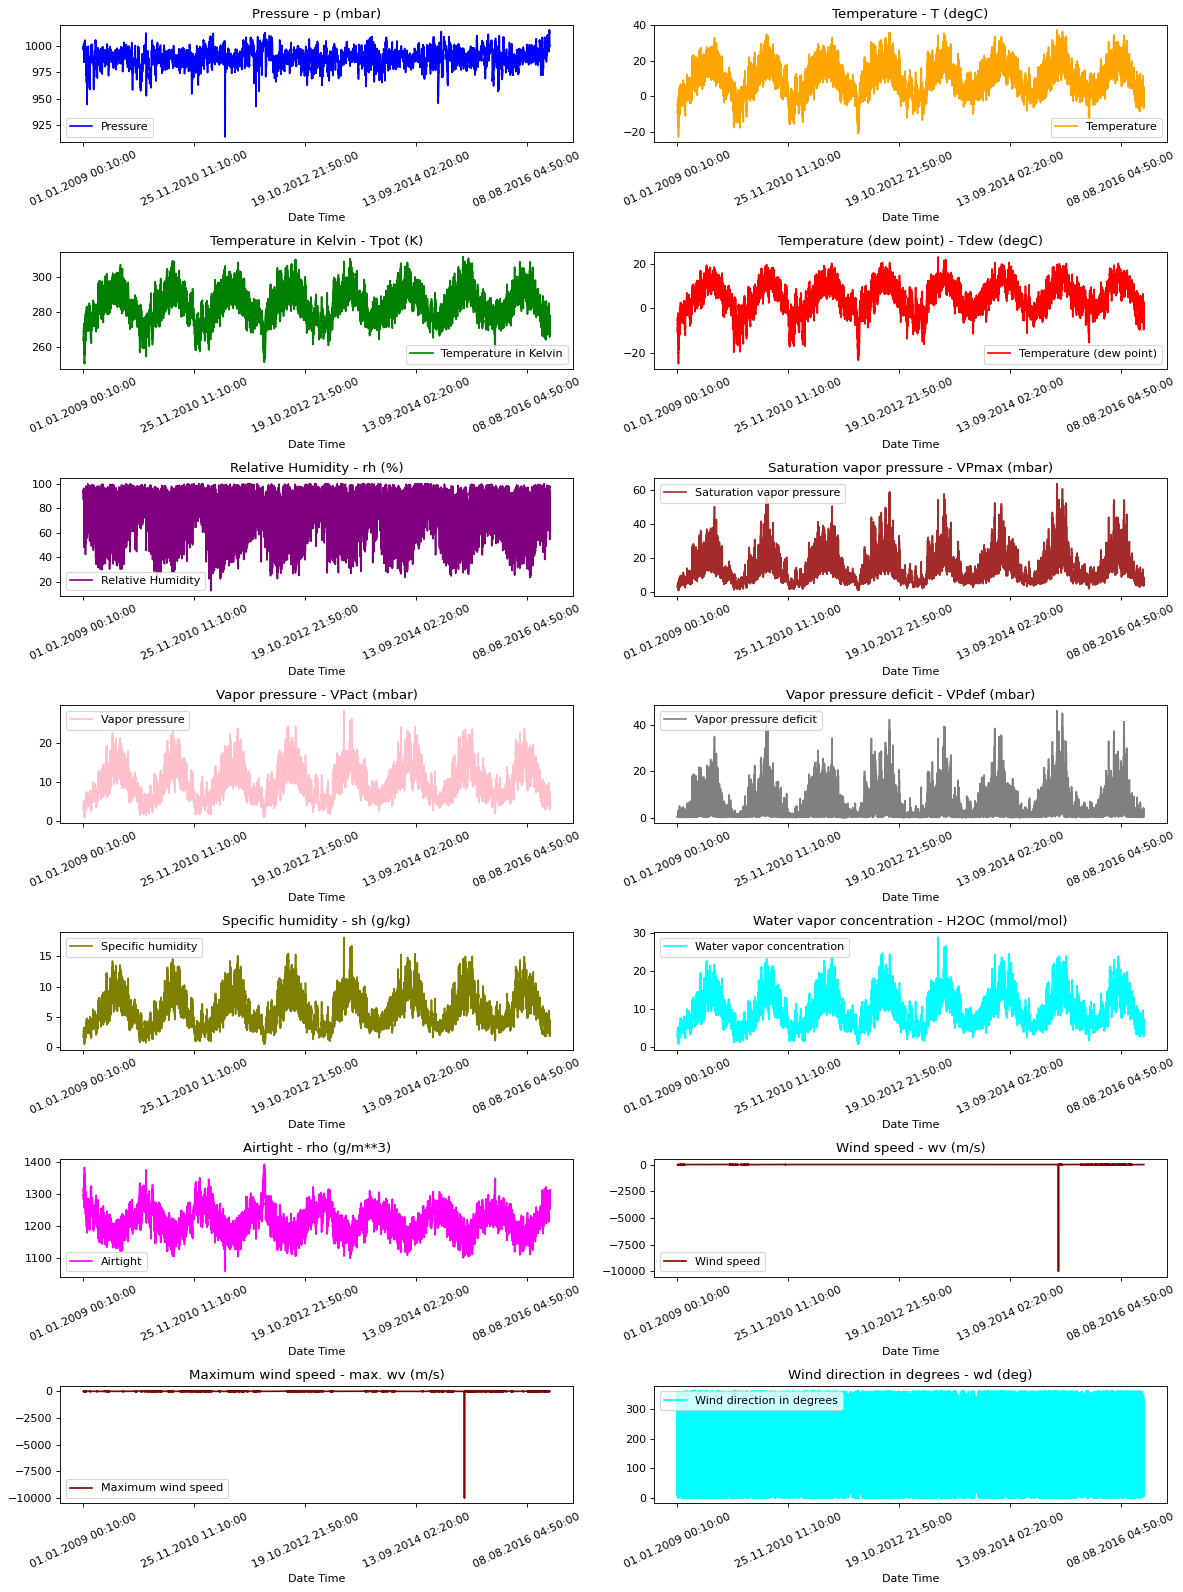

In [26]:
titles = [
    "Pressure", "Temperature", "Temperature in Kelvin", "Temperature (dew point)",
    "Relative Humidity", "Saturation vapor pressure", "Vapor pressure",
    "Vapor pressure deficit", "Specific humidity", "Water vapor concentration",
    "Airtight", "Wind speed", "Maximum wind speed", "Wind direction in degrees",
]

feature_keys = [
    "p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)",
    "VPmax (mbar)", "VPact (mbar)", "VPdef (mbar)", "sh (g/kg)",
    "H2OC (mmol/mol)", "rho (g/m**3)", "wv (m/s)", "max. wv (m/s)", "wd (deg)",
]

colors = [
    "blue", "orange", "green", "red", "purple",
    "brown", "pink", "gray", "olive", "cyan", "magenta","maroon","maroon", "cyan"
]

date_time_key = "Date Time"


def plot_single_feature(ax, title, key, color, time_data, data):
    t_data = data[key]
    t_data.index = time_data
    t_data.plot(ax=ax, color=color, title="{} - {}".format(title, key), rot=25)
    ax.legend([title])


def show_raw_visualization(data):
    time_data = data[date_time_key]
    fig, axes = plt.subplots(
        nrows=7, ncols=2, figsize=(15, 20), dpi=80, facecolor="w", edgecolor="k"
    )
    for i, (title, key, color) in enumerate(zip(titles, feature_keys, colors)):
        plot_single_feature(axes[i // 2, i % 2], title, key, color, time_data, data)
    plt.tight_layout()


show_raw_visualization(df)




### **OBSERVATION FROM VISUALIZATION**
Upon visualizing the data, it was observed that 3 of the features did not exhibit a consistent pattern. This inconsistency might indicate noise, anomalies, or external factors influencing these features. Further investigation or preprocessing is required to handle these irregularities effectively.

# **Data Preprocessing**

In [8]:
import numpy as np

split_fraction = 0.715
train_split = int(split_fraction * len(df))
step = 6

past = 720
future = 72
learning_rate = 0.001
batch_size = 256
epochs = 10


def normalize_data(data, train_split):
    data_mean = np.mean(data[:train_split], axis=0)
    data_std = np.std(data[:train_split], axis=0)
    normalized_data = (data - data_mean) / data_std
    return normalized_data


In [ ]:
print(
    "The selected parameters are:",
    ", ".join([titles[i] for i in [0, 1, 5, 7, 8, 10, 11]]),
)
selected_features = [feature_keys[i] for i in [0, 1, 5, 7, 8, 10, 11]]
features = df[selected_features]
features.index = df[date_time_key]
features.head()

features = normalize_data(features.values, train_split)
features = pd.DataFrame(features)
features.head()

train_data = features.loc[0 : train_split - 1]
val_data = features.loc[train_split:]


The selected parameters are: Pressure, Temperature, Saturation vapor pressure, Vapor pressure deficit, Specific humidity, Airtight, Wind speed


# **Train the dataset**

In [19]:
features

,0,1,2,3,4,5,6
0,0.955451,-2.000020,-1.319782,-0.788479,-1.500927,2.237658,-0.732997
1,0.961528,-2.045185,-1.332806,-0.790561,-1.519521,2.287838,-0.936002
2,0.956666,-2.056766,-1.335410,-0.792642,-1.523239,2.298608,-1.283076
3,0.954236,-2.033604,-1.328898,-0.794724,-1.508364,2.272906,-1.184847
4,0.954236,-2.028972,-1.327596,-0.794724,-1.508364,2.268256,-1.197944
...,...,...,...,...,...,...,...
420546,1.386902,-1.540264,-1.164797,-0.580316,-1.456301,1.876123,-0.968745
420547,1.369887,-1.459199,-1.132237,-0.534520,-1.452583,1.789472,-0.660963
420548,1.356518,-1.437195,-1.123121,-0.511622,-1.460020,1.763770,-0.700254
420549,1.355303,-1.561109,-1.172611,-0.571990,-1.482333,1.890320,-0.431764


In [ ]:
start = past + future
end = start + train_split

# Assuming 'train_data' and 'normalized_features' are available

# Extracting input features (x_train) and target variable (y_train)
TARGET_InDEX = 1  # Temperature
x_train = train_data.iloc[start:end, :].values
y_train = features.iloc[start:end, TARGET_InDEX].values.reshape(-1, 1)

sequence_length = int(past / step)

# Printing the shapes for verification
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("Sequence length:", sequence_length)


x_train shape: (299901, 7)
y_train shape: (300693, 1)
Sequence length: 120


In [11]:
start = past + future
end = start + train_split

# Assuming 'train_data', 'features', 'past', 'future', and 'step' are available

x_train = train_data.iloc[start:end, :7].values
y_train = features.iloc[start:end, 1].values.reshape(-1, 1)

sequence_length = int(past / step)

In [12]:
dataset_train = keras.preprocessing.timeseries_dataset_from_array(
    x_train,
    y_train,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)

In [13]:
x_end = len(val_data) - past - future

label_start = train_split + past + future

x_val = val_data.iloc[:x_end][[i for i in range(7)]].values
y_val = features.iloc[label_start:][[1]]

dataset_val = keras.preprocessing.timeseries_dataset_from_array(
    x_val,
    y_val,
    sequence_length=sequence_length,
    sampling_rate=step,
    batch_size=batch_size,
)


for batch in dataset_train.take(1):
    inputs, targets = batch

print("Input shape:", inputs.numpy().shape)
print("Target shape:", targets.numpy().shape)

Input shape: (256, 120, 7)
Target shape: (256, 1)


# **Training**

### **REASON FOR USING LSTM?**

LSTM, or Long Short-Term Memory, is a type of recurrent neural network (RNN) architecture designed to model sequential data and capture long-term dependencies.

#### **Key Components of LSTM:**
1. **Cell State**: Acts as a memory that carries information across time steps.
2. **Forget Gate**: Decides what information to discard from the cell state.
3. **Input Gate**: Determines what new information to store in the cell state.
4. **Output Gate**: Controls what information to output at each time step.

In [15]:
inputs = keras.layers.Input(shape=(inputs.shape[1], inputs.shape[2]))
lstm_out = keras.layers.LSTM(32)(inputs)
outputs = keras.layers.Dense(1)(lstm_out)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss="mse")
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 120, 7)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,153 (20.13 KB)

 Trainable params: 5,153 (20.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Assuming 'model', 'dataset_train', 'epochs', and 'dataset_val' are available

path_checkpoint = "model_checkpoint.weights.h5"

es_callback = EarlyStopping(monitor="val_loss", min_delta=0, patience=7)

modelckpt_callback = ModelCheckpoint(
    monitor="val_loss",
    filepath=path_checkpoint,
    verbose=1,
    save_weights_only=True,
    save_best_only=True,
)

history = model.fit(
    dataset_train,
    epochs=epochs,
    validation_data=dataset_val,
    callbacks=[es_callback, modelckpt_callback],
)


Epoch 1/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.5496
Epoch 1: val_loss improved from inf to 0.36981, saving model to model_checkpoint.weights.h5
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 105s 88ms/step - loss: 0.5495 - val_loss: 0.3698
Epoch 2/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3668
Epoch 2: val_loss did not improve from 0.36981
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 104s 89ms/step - loss: 0.3668 - val_loss: 0.3807
Epoch 3/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.3383
Epoch 3: val_loss did not improve from 0.36981
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 105s 89ms/step - loss: 0.3382 - val_loss: 0.4226
Epoch 4/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.3128
Epoch 4: val_loss did not improve from 0.36981
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 105s 90ms/step - loss: 0.3128 - val_loss: 0.4179
Epoch 5/10
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 0.3066
Epoch 5: val_loss did not improve from 0.36981
1169/1169 ━━━━━━━━━━━━━━━━━━━━ 105s 90ms/step - lo

**# Evaluate the Model**

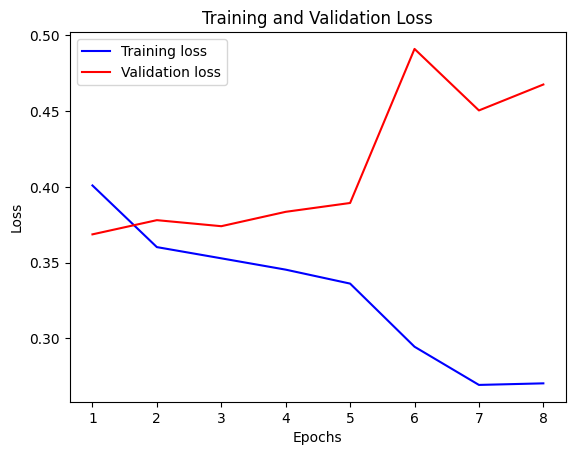

In [12]:
import matplotlib.pyplot as plt

def visualize_loss(history, title):
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]
    epochs = range(1, len(loss) + 1)

    plt.plot(epochs, loss, "b", label="Training loss")
    plt.plot(epochs, val_loss, "r", label="Validation loss")
    
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

visualize_loss(history, "Training and Validation Loss")


### **Conclusion from Training and Validation Loss Graph**

The training loss started high and decreased over epochs, indicating that the model was learning and improving its performance on the training data. However, the validation loss started low and increased over time, suggesting that the model began to overfit the training data. This overfitting implies that the model's ability to generalize to unseen data is compromised, and it is memorizing the training data rather than learning meaningful patterns.

# **Prediction**

8/8 [==============================] - 0s 3ms/step


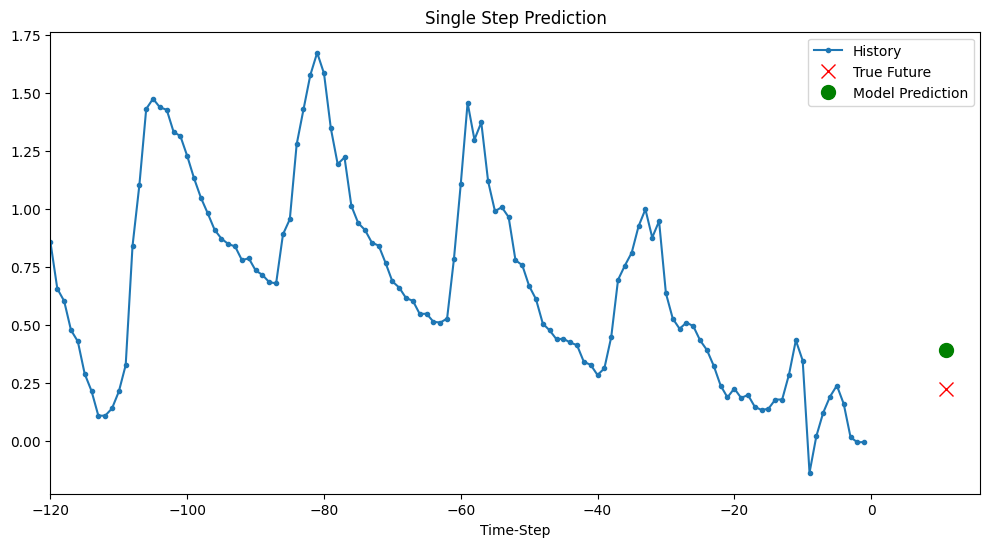

8/8 [==============================] - 0s 3ms/step


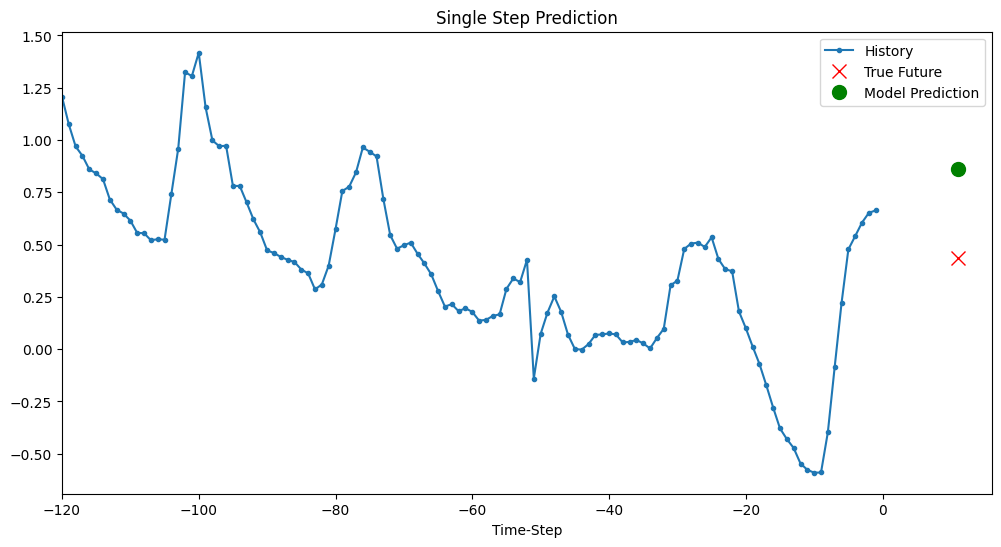

8/8 [==============================] - 0s 3ms/step


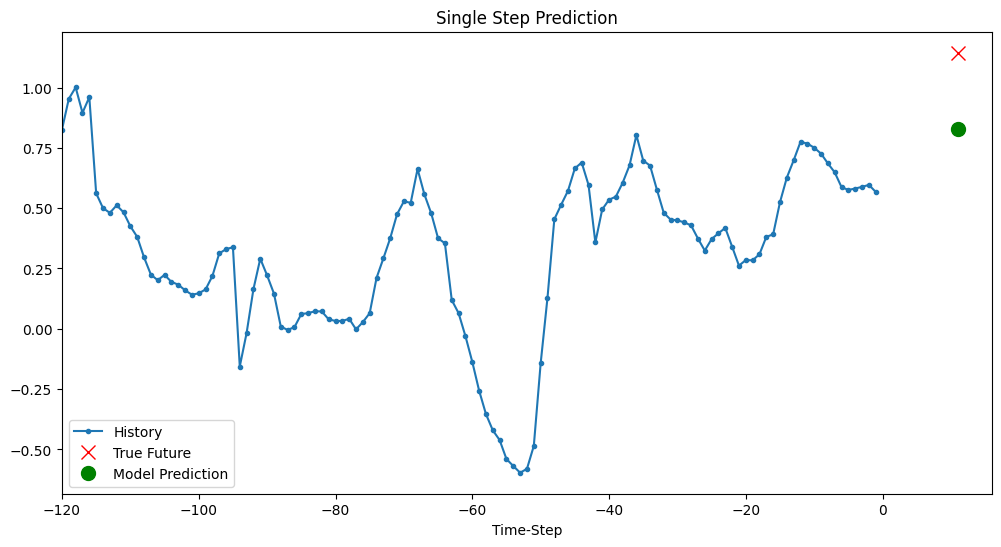

8/8 [==============================] - 0s 3ms/step


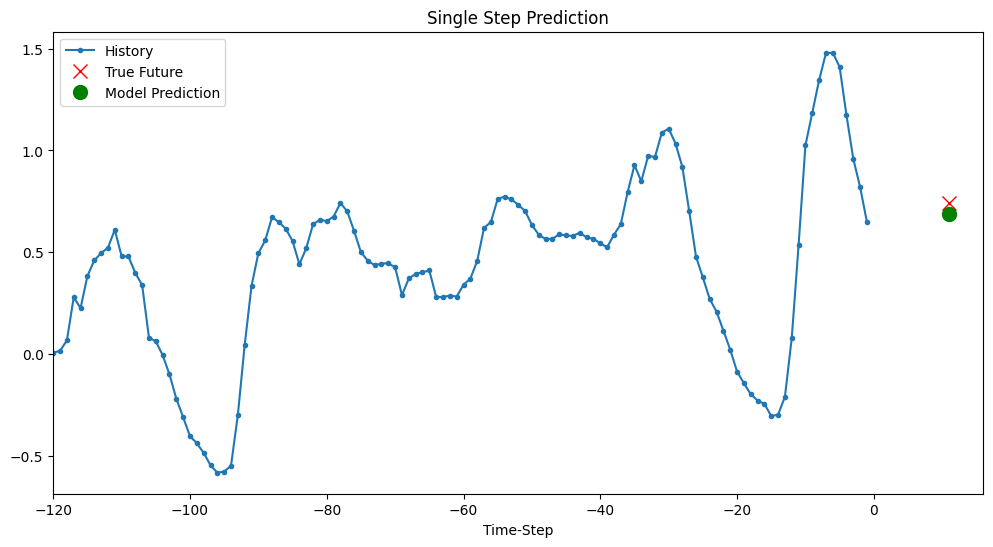

8/8 [==============================] - 0s 3ms/step


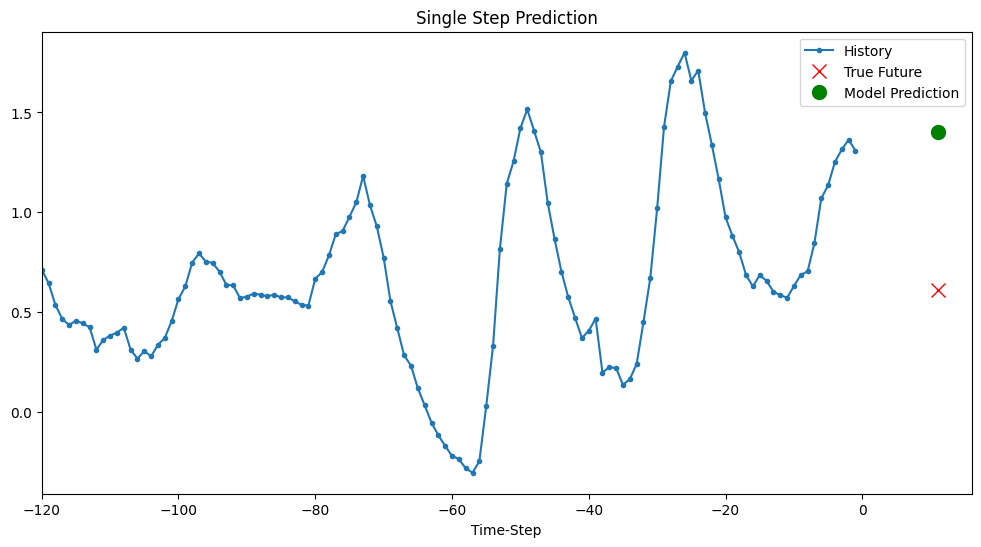

In [13]:
def show_plot(plot_data, delta, title):
    labels = ["History", "True Future", "Model Prediction"]
    marker = [".-", "rx", "go"]
    time_steps = list(range(-(plot_data[0].shape[0]), 0))

    if delta:
        future = delta
    else:
        future = 0

    plt.figure(figsize=(12, 6))
    plt.title(title)

    for i, val in enumerate(plot_data):
        if i:
            plt.plot(time_steps[-1] + future, plot_data[i], marker[i], markersize=10, label=labels[i])
        else:
            plt.plot(time_steps, plot_data[i].flatten(), marker[i], label=labels[i])

    plt.legend()
    plt.xlim([time_steps[0], time_steps[-1] + future + 5])
    plt.xlabel("Time-Step")
    plt.show()

for x, y in dataset_val.take(5):
    show_plot(
        [x[0][:, 1].numpy(), y[0].numpy(), model.predict(x)[0]],
        12,
        "Single Step Prediction",
    )
